#Proyecto Final

Nombre: Santiago Ajala Ramos

In [ ]:
#conectar al drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Leer Excel y una hoja en especifico
import pandas as pd
df=pd.read_excel("/content/drive/MyDrive/Maestría Ciencia de Datos/Fundamentos Ciencia de Datos/equivalencia de zonas censales y de movilidad total-2.xlsx",
                 sheet_name="Base_datos")
df.head()

,SbjNum,Q0,Q0b,Q1a,Q1b,Q1c,Q1d,Q2,Q2si,Q2no,...,Q4,Q5,Q6,Q7,Q8_1,Q8_2,T_78_1,Q10,WP,Num
0,SbjNum,Q0. Cuál es la dirección del hogar?,Q0b. A qué Zonificación corresponde:,Q1a. Edad de entrevistado: (años),Q1b. Género del entrevistado:,Q1c. Estado Civil del entrevistado:,Q1d. Ocupación:,"Salió de casa ayer? (Si es lunes, preguntar po...",Cuántos desplazamientos hizo: “Por desplazamie...,Por qué MOTIVO no se desplazó?,...,Características del Entrevistado: Número de v...,Tiene licencia de conducir?,Tiene disponibilidad de vehículo?,Ante la posibilidad de implantación de un sist...,¿Me podría indicar el por qué de su respuesta ...,¿Me podría indicar el por qué de su respuesta ...,Número de contactos que tuvo que hacer antes d...,Nombres del Encuestador:,Factor de Expansión,Número
1,1048982,DE LAS ALCABALAS Y DEL OBRERO,Z02,35,Femenino,Casado/a,Ama de casa - No trabaja,Si,2,NaN,...,0,No,No,Si,Ahorro de tiempo,NaN,6,CONCEPCION ALCIVAR,57.267122,1
2,1048993,DE LAS ALCABALAS 2-80 Y BARRIAL BLANCO,Z10,20,Masculino,Soltero/a,Estudiante - No trabaja,Si,2,NaN,...,0,No,No,Si,Seguridad y fiabilidad,NaN,1,CONCEPCION ALCIVAR,57.355685,2
3,1049018,CALLE DEL CHORRO 3-74 Y BARRIAL BLANCO,Z10,21,Masculino,Unión libre,Empleado privado,Si,2,NaN,...,0,No,No,Si,Ahorro de tiempo,NaN,2,CONCEPCION ALCIVAR,57.355685,3
4,1049034,BARRIAL BLANCO Y DE LAS ALCABALAS,Z10,16,Femenino,Soltero/a,Estudiante - No trabaja,Si,2,NaN,...,0,Menor de edad,Menor de edad,Si,Seguridad y fiabilidad,NaN,4,CONCEPCION ALCIVAR,85.062537,4


In [ ]:
#Seleccionar columnas para el estudio
df=df[['Q1a','Q1b','Q1c','Q1d','Q2si','Q3_11si','Q3_11sib','Q3_12','Q3_13','Q3_13b','Q3_14','Q3_15_O1','Q3_16','Q4','Q5','Q6']]

In [ ]:
#Cambiar nombre columnas
df.rename(columns={'Q1a': 'edad',
                   'Q1b': 'genero',
                   'Q1c': 'estado_civil',
                   'Q1d': 'ocupacion',
                   'Q2si':'desplazamientos',
                   'Q3_11si':'direccion_inicio',
                   'Q3_11sib':'zona_inicio',
                   'Q3_12':'motivo',
                   'Q3_13':'direccion_fin',
                   'Q3_13b':'zona_fin',
                   'Q3_14':'hora_inicio',
                   'Q3_15_O1':'medio_transporte',
                   'Q3_16':'duracion',
                   'Q4':'n_vehiculos',
                   'Q5':'licencia',
                   'Q6':'vehiculo'
                   }, inplace=True)

In [ ]:
#Eliminar filas
df=df.drop(0)
df=df.drop(5035)
df=df.drop(5036)
df=df.reset_index(drop=True)

In [ ]:
df

,edad,genero,estado_civil,ocupacion,desplazamientos,direccion_inicio,zona_inicio,motivo,direccion_fin,zona_fin,hora_inicio,medio_transporte,duracion,n_vehiculos,licencia,vehiculo
0,35,Femenino,Casado/a,Ama de casa - No trabaja,2,DE LAS ALCABALAS Y DEL OBRERO,Z10,Médico/ hospital,GIL RAMIRES DAVALOS,Z02,14:00:00,A pie,7,0,No,No
1,20,Masculino,Soltero/a,Estudiante - No trabaja,2,DE LAS ALCABALAS 2-80 Y BARRIAL BLANCO,Z10,Pasear/ Acompañar personas/ Visita amigo familiar,"AV. DE LAS AMERICAS, CENTRAL SUR",Z17,09:30:00,A pie,5,0,No,No
2,21,Masculino,Unión libre,Empleado privado,2,CALLE DEL CHORRO 3-74 Y BARRIAL BLANCO,Z10,Trabajo,"CARLOS TOSSI, PARQUE INDUSTRIAL",Z02,06:20:00,A pie,15,0,No,No
3,16,Femenino,Soltero/a,Estudiante - No trabaja,2,BARRIAL BLANCO Y DE LAS ALCABALAS,Z10,Estudios / Formación,GAPAL,Z02,07:00:00,A pie,23,0,Menor de edad,Menor de edad
4,25,Femenino,Soltero/a,Empleado privado,4,CALLE DEL CHORRO 3-64 Y BARRIAL BLANCO,Z10,Pasear/ Acompañar personas/ Visita amigo familiar,GONZALEZ SUAREZ Y OCTAVIO DIAZ,Z02,15:00:00,A pie,30,0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5029,25,Femenino,Casado/a,Estudiante - Trabaja,3,CAMINO DEL TEJAR Y ARTURO VENEGAS,Z34,Trabajo,PANCAS Y VERVENA,Z33,07:35:00,Autobús urbano,10,1,No,Si
5030,47,Femenino,Casado/a,Ama de casa - No trabaja,2,CALLE DE LA CRUZ ENTRE LAS LIBERTADORES Y CALL...,Z34,Pasear/ Acompañar personas/ Visita amigo familiar,AV ORDOÑEZ LAZO Y RIO AMARILLO,Z34,15:00:00,A pie,15,0,No,No
5031,54,Femenino,Viudo/a,Ama de casa - No trabaja,2,AV ORDOÑEZ LAZO Y ARTURO VENEGAS,Z34,Compras,AV AMERICASZ ARIZAGAS RAMIREZ,Z39,10:00:00,Taxi,10,0,No,No
5032,29,Femenino,Soltero/a,Profesional independiente,2,CALLE DE LA CRUZ Y LOS LIBERTADORES,Z34,Gestiones personales,LUIS CORDERO ENTRE GRAN COLOMBIA Y MARISCAL LA...,Z02,08:00:00,Coche como acompañante,15,1,Si,No


In [ ]:
#Eliminar valores faltantes
df=df.dropna()
#Se eliminan 8 filas del total de dataset que dandonos 5026 regitros

In [ ]:
df.count()

,0
edad,5026
genero,5026
estado_civil,5026
ocupacion,5026
desplazamientos,5026
direccion_inicio,5026
zona_inicio,5026
motivo,5026
direccion_fin,5026
zona_fin,5026


In [ ]:
# Columnas a convertir a tipo string
cols_string = ['genero', 'estado_civil', 'ocupacion', 'direccion_inicio', 'zona_inicio', 'motivo', 'direccion_fin', 'zona_fin', 'hora_inicio', 'medio_transporte', 'licencia', 'vehiculo']

# Columnas a convertir a tipo int
cols_int = ['edad', 'desplazamientos', 'duracion', 'n_vehiculos']

# Aplicar cambios
for col in cols_string:
    df[col] = df[col].astype('string')

for col in cols_int:
    df[col] = df[col].astype(int)


<ipython-input-9-2402434073d4>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype('string')
<ipython-input-9-2402434073d4>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(int)
<ipython-input-9-2402434073d4>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing

In [ ]:
df.dtypes

,0
edad,int64
genero,string[python]
estado_civil,string[python]
ocupacion,string[python]
desplazamientos,int64
direccion_inicio,string[python]
zona_inicio,string[python]
motivo,string[python]
direccion_fin,string[python]
zona_fin,string[python]


In [ ]:
#Ver variables numericas
df.describe()

,edad,desplazamientos,duracion,n_vehiculos
count,5026.000000,5026.000000,5026.000000,5026.000000
mean,32.994031,2.284918,22.124950,0.829885
std,11.567993,0.670931,15.945052,0.810571
min,16.000000,1.000000,1.000000,0.000000
25%,23.000000,2.000000,10.000000,0.000000
50%,32.000000,2.000000,20.000000,1.000000
75%,42.000000,2.000000,30.000000,1.000000
max,55.000000,5.000000,120.000000,10.000000


In [ ]:
df.groupby('n_vehiculos')['edad'].count()

,edad
n_vehiculos,
0,1868
1,2335
2,685
3,107
4,20
5,5
6,5
10,1


In [ ]:
#Eliminar fila donde n_vehiculos es igual a 10
df=df.drop(df[df['n_vehiculos']==10].index)

In [ ]:
df=df.reset_index(drop=True)

In [ ]:
df.groupby('n_vehiculos')['edad'].count()

,edad
n_vehiculos,
0,1868
1,2335
2,685
3,107
4,20
5,5
6,5


In [ ]:
#Eliminar registros donde en la columna hora_inicio empieze con Z
df=df[~df['hora_inicio'].str.startswith('Z')]
df=df.reset_index(drop=True)

In [ ]:
#Quitamos las columnas direccion_inicio y direccion_fin
df=df.drop(['direccion_inicio', 'direccion_fin'], axis=1)

# Variables categoricas

## estado civil

In [ ]:
df['estado_civil'].unique()

<StringArray>
['Casado/a', 'Soltero/a', 'Unión libre', 'Divorciado/a', 'Separado/a',
 'Viudo/a']
Length: 6, dtype: string

In [ ]:
df.groupby('estado_civil')['edad'].count()

,edad
estado_civil,
Casado/a,2664
Divorciado/a,202
Separado/a,34
Soltero/a,1883
Unión libre,168
Viudo/a,72


## ocupacion

In [ ]:
df['ocupacion'].unique()

<StringArray>
[ 'Ama de casa - No trabaja',   'Estudiante - No trabaja',
          'Empleado privado', 'Profesional independiente',
   'Propietario-Comerciante',          'Empleado público',
    'Jubilado - pensionista',      'Estudiante - Trabaja',
                     'Otro:']
Length: 9, dtype: string

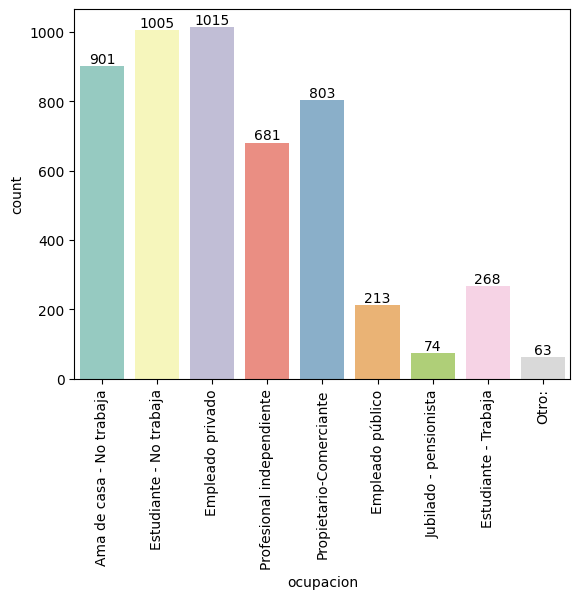

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Establece una paleta de colores
palette = sns.color_palette("Set3", n_colors=len(df['ocupacion'].unique()))
# sns.set(rc={'figure.figsize':(12,8)}) # Establece el tamaño de la figura
ax = sns.countplot(data=df, x='ocupacion', hue='ocupacion', palette=palette, legend=False)
# Asegúrate de que las etiquetas del eje x estén asociadas con una ubicación específica
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
# Agrega etiquetas con el número de cada categoría
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
# Muestra el gráfico
plt.savefig('ocupacion.png')
plt.show()

In [ ]:
# Define un diccionario de mapeo para las nuevas categorías
mapeo_categorias = {
    'Estudiante': ['Estudiante - No trabaja','Estudiante - Trabaja'],
    'Empleado': ['Empleado privado','Empleado público'],
    'Independiente/Comerciante': ['Profesional independiente','Propietario-Comerciante'],
    'Ama de casa':['Ama de casa - No trabaja'],
    'Jubilado/Otro':['Jubilado - pensionista','Otro:']
}

# Crea una nueva columna con las categorías recategorizadas
df['ocupacion'] = df['ocupacion'].apply(
    lambda x: next((categoria for categoria, subcategorias in mapeo_categorias.items() if x in subcategorias), x)
)

In [ ]:
df.groupby('ocupacion')['edad'].count()

,edad
ocupacion,
Ama de casa,901
Empleado,1228
Estudiante,1273
Independiente/Comerciante,1484
Jubilado/Otro,137


## motivo

In [ ]:
df['motivo'].unique()

<StringArray>
[                                 'Médico/ hospital',
 'Pasear/ Acompañar personas/ Visita amigo familiar',
                                           'Trabajo',
                              'Estudios / Formación',
                                           'Compras',
                                  'Ocio / diversión',
                              'Gestiones personales',
                                             'Otros',
                     'Comida no por motivos de ocio',
     'Vuelta a casa desde trabajo/estudio/formación',
                 'Vuelta a casa desde otros motivos']
Length: 11, dtype: string

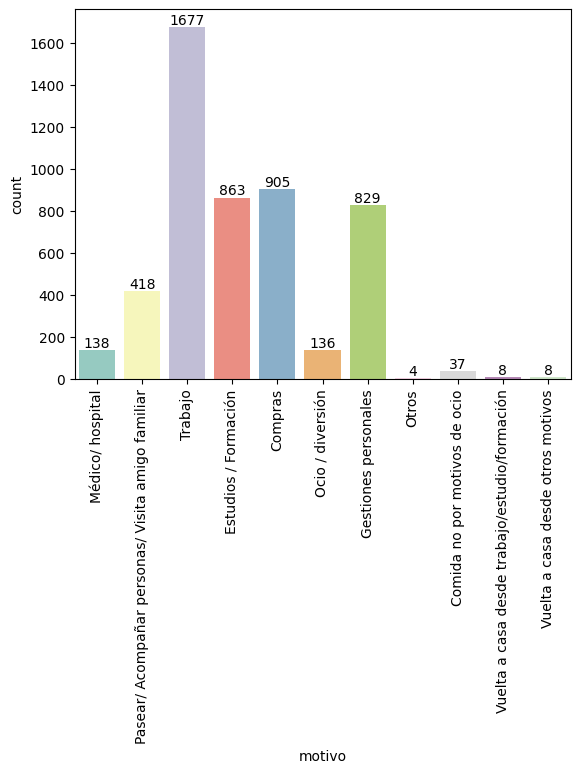

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Establece una paleta de colores
palette = sns.color_palette("Set3", n_colors=len(df['motivo'].unique()))
# sns.set(rc={'figure.figsize':(12,8)}) # Establece el tamaño de la figura
ax = sns.countplot(data=df, x='motivo', hue='motivo', palette=palette, legend=False)
# Asegúrate de que las etiquetas del eje x estén asociadas con una ubicación específica
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
# Agrega etiquetas con el número de cada categoría
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
# Muestra el gráfico
plt.savefig('motivo.png')
plt.show()

In [ ]:
# Define un diccionario de mapeo para las nuevas categorías
mapeo_categorias = {
    'Estudios': ['Estudios / Formación','Vuelta a casa desde trabajo/estudio/formación'],
    'Personal': ['Gestiones personales','Médico/ hospital','Pasear/ Acompañar personas/ Visita amigo familiar'],
    'Otros': ['Ocio / diversión','Comida no por motivos de ocio','Otros','Vuelta a casa desde otros motivos'],
}

# Crea una nueva columna con las categorías recategorizadas
df['motivo'] = df['motivo'].apply(
    lambda x: next((categoria for categoria, subcategorias in mapeo_categorias.items() if x in subcategorias), x)
)

In [ ]:
df.groupby('motivo')['edad'].count()

,edad
motivo,
Compras,905
Estudios,871
Otros,185
Personal,1385
Trabajo,1677


## medio_transporte

In [ ]:
df['medio_transporte'].unique()

<StringArray>
[                       'A pie',               'Autobús urbano',
           'Autobús de empresa',       'Coche como acompañante',
         'Coche como conductor',                         'Taxi',
              'Autobús escolar',   'Motocicleta como conductor',
                    'Bicicleta',                'Autobús otros',
          'Autobús interurbano', 'Motocicleta como acompañante',
                        'Otros']
Length: 13, dtype: string

In [ ]:
#Eiliminar filas donde medio de transporte es Otros ya qe solo hay dos registros
df=df[df['medio_transporte']!='Otros']
df=df.reset_index(drop=True)

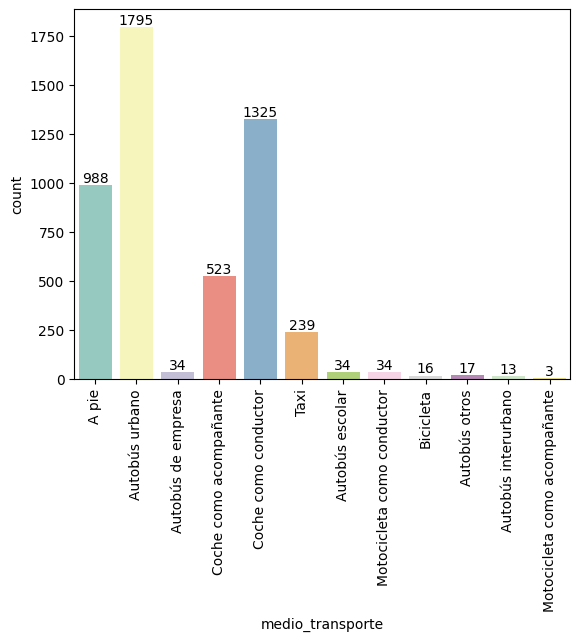

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Establece una paleta de colores
palette = sns.color_palette("Set3", n_colors=len(df['medio_transporte'].unique()))
# sns.set(rc={'figure.figsize':(12,8)}) # Establece el tamaño de la figura
ax = sns.countplot(data=df, x='medio_transporte', hue='medio_transporte', palette=palette, legend=False)
# Asegúrate de que las etiquetas del eje x estén asociadas con una ubicación específica
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
# Agrega etiquetas con el número de cada categoría
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
# Muestra el gráfico
plt.savefig('medio_transporte.png')
plt.show()

In [ ]:
# Define un diccionario de mapeo para las nuevas categorías
mapeo_categorias = {
    'Transporte no motorizado': ['A pie','Bicicleta'],
    'Transporte público': ['Autobús urbano', 'Autobús de empresa', 'Autobús escolar', 'Autobús otros', 'Autobús interurbano','Taxi'],
    'Vehículo privado': ['Motocicleta como conductor', 'Motocicleta como acompañante','Coche como conductor','Coche como acompañante'],
}

# Crea una nueva columna con las categorías recategorizadas
df['medio_transporte'] = df['medio_transporte'].apply(
    lambda x: next((categoria for categoria, subcategorias in mapeo_categorias.items() if x in subcategorias), x)
)


In [ ]:
df.groupby('medio_transporte')['edad'].count()

,edad
medio_transporte,
Transporte no motorizado,1004
Transporte público,2132
Vehículo privado,1885


## licencia y vehiculo

In [ ]:
df['licencia'].unique()

<StringArray>
['No', 'Menor de edad', 'Si']
Length: 3, dtype: string

In [ ]:
df['vehiculo'].unique()

<StringArray>
['No', 'Menor de edad', 'Si']
Length: 3, dtype: string

In [ ]:
# Define un diccionario de mapeo para las nuevas categorías
mapeo_categorias = {
    'Si': ['Si'],
    'No': ['No','Menor de edad']
}

# Crea una nueva columna con las categorías recategorizadas
df['licencia'] = df['licencia'].apply(
    lambda x: next((categoria for categoria, subcategorias in mapeo_categorias.items() if x in subcategorias), x)
)
df['vehiculo'] = df['vehiculo'].apply(
    lambda x: next((categoria for categoria, subcategorias in mapeo_categorias.items() if x in subcategorias), x)
)

## Zona Inicio y Zona Fin


In [ ]:
len(df['zona_inicio'].unique())

43

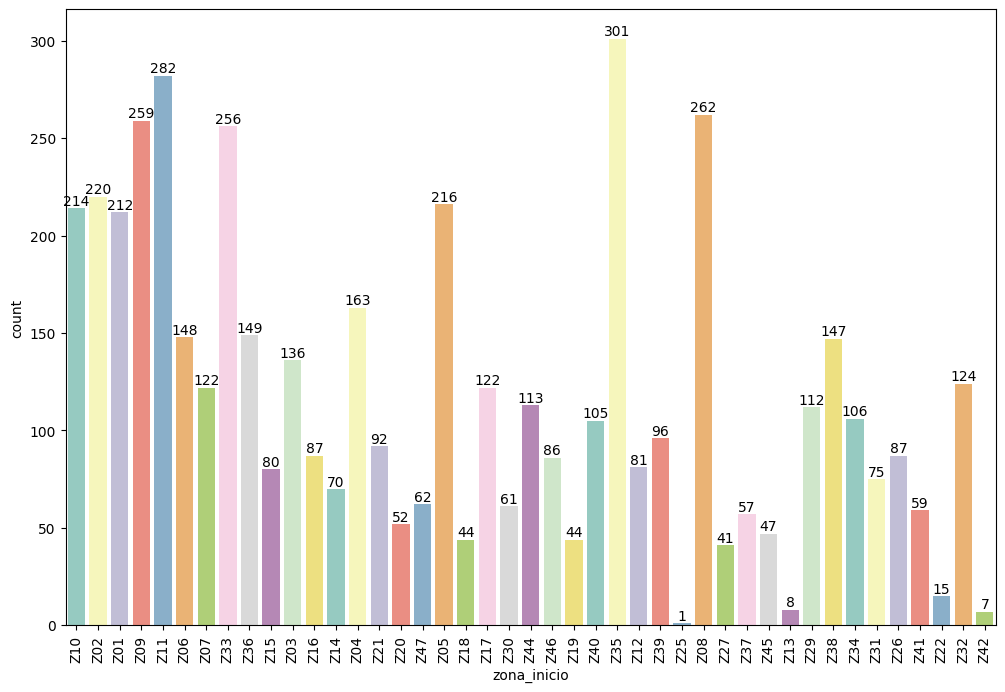

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#definir tamanio grafico
plt.figure(figsize=(12, 8))
# Establece una paleta de colores
palette = sns.color_palette("Set3", n_colors=len(df['zona_inicio'].unique()))
# sns.set(rc={'figure.figsize':(12,8)}) # Establece el tamaño de la figura
ax = sns.countplot(data=df, x='zona_inicio', hue='zona_inicio', palette=palette, legend=False)
# Asegúrate de que las etiquetas del eje x estén asociadas con una ubicación específica
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
# Agrega etiquetas con el número de cada categoría
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
# Muestra el gráfico
plt.savefig('zona_inicio.png')
plt.show()

In [ ]:
len(df['zona_fin'].unique())

50

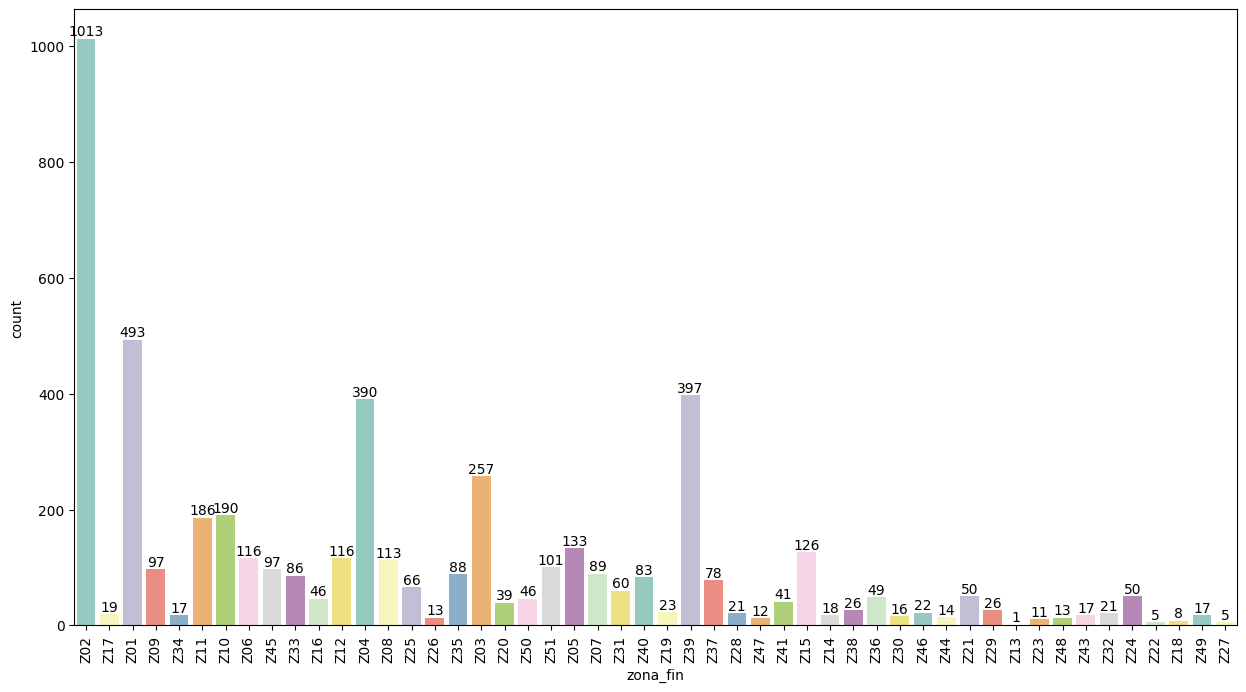

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#definir tamanio grafico
plt.figure(figsize=(15, 8))
# Establece una paleta de colores
palette = sns.color_palette("Set3", n_colors=len(df['zona_fin'].unique()))
# sns.set(rc={'figure.figsize':(12,8)}) # Establece el tamaño de la figura
ax = sns.countplot(data=df, x='zona_fin', hue='zona_fin', palette=palette, legend=False)
# Asegúrate de que las etiquetas del eje x estén asociadas con una ubicación específica
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
# Agrega etiquetas con el número de cada categoría
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
# Muestra el gráfico
plt.savefig('zona_fin.png')
plt.show()

En este caso tenemos muchas categorias tanto en la zona inicio y en la zona fin. Como tenemos las coordenadas de los centroide de las zonas por lo que podemos agrupar. Utilizamos el método de K-means

In [ ]:
zonas=pd.read_csv("/content/drive/MyDrive/Maestría Ciencia de Datos/Fundamentos Ciencia de Datos/zonas.csv",sep=';')
zonas.head()

,ZONA,X_CENT,Y_CENT
0,1,721971,9680163
1,2,722009,9679276
2,3,722039,9678076
3,4,720723,9678573
4,5,719827,9679272


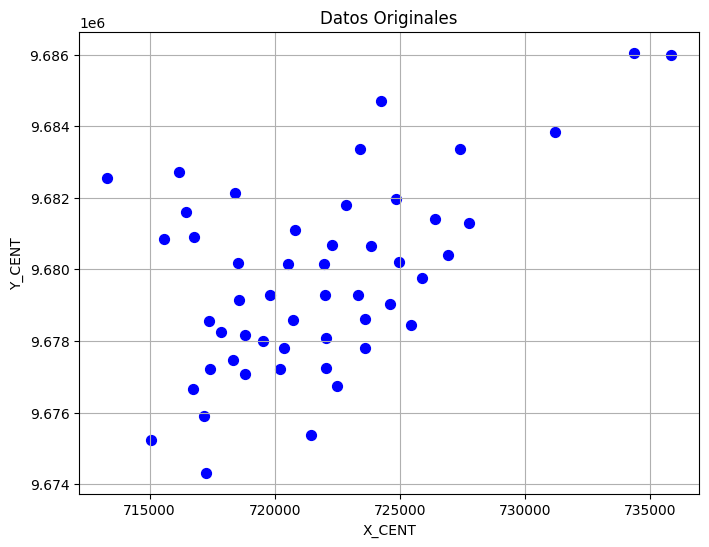

In [ ]:
import matplotlib.pyplot as plt
import numpy as npm
# Visualizar los datos originales
plt.figure(figsize=(8, 6))
plt.scatter(zonas['X_CENT'],zonas['Y_CENT'], c='blue', s=50)
plt.title('Datos Originales')
plt.xlabel('X_CENT')
plt.ylabel('Y_CENT')
plt.grid(True)
plt.show()

In [ ]:
#Grafico del codo
from sklearn.cluster import KMeans
score=[]
for i in range(2,15):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(zonas)
  score.append(kmeans.inertia_)

In [ ]:
len(score)
score

[682670777.1193547,
 450362858.9702381,
 292649278.30417293,
 203115710.2916667,
 174644588.52849928,
 158654073.72130647,
 129804338.5777778,
 123260716.94444445,
 107836515.95833333,
 87693867.63452381,
 77400919.21785715,
 64850163.79166668,
 57117615.591666676]

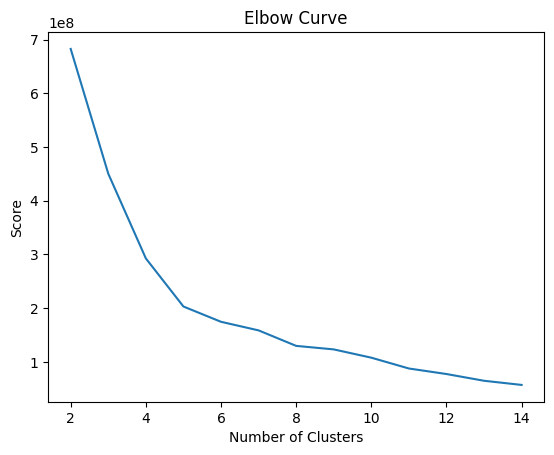

In [ ]:
#graficamos los valores
plt.plot(range(2,15),score) # Changed range to match the number of clusters used in KMeans
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.savefig('2.1_elbow_curve.png')
plt.show()

In [ ]:
# Silhoutte Score
from sklearn.metrics import silhouette_score
silhouette_scores = []
for i in range(2,15):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(zonas)
  cluster_labels = kmeans.labels_
  silhouette_avg = silhouette_score(zonas, cluster_labels)
  print(f"For n_clusters = {i}, the silhouette score is {silhouette_avg}")


For n_clusters = 2, the silhouette score is 0.4412846312160218
For n_clusters = 3, the silhouette score is 0.3618101095278898
For n_clusters = 4, the silhouette score is 0.35327034994300227
For n_clusters = 5, the silhouette score is 0.39364641919385024
For n_clusters = 6, the silhouette score is 0.3727460392666434
For n_clusters = 7, the silhouette score is 0.3448575254652828
For n_clusters = 8, the silhouette score is 0.3277455993777109
For n_clusters = 9, the silhouette score is 0.284095415195407
For n_clusters = 10, the silhouette score is 0.2733806936268863
For n_clusters = 11, the silhouette score is 0.2907180315434707
For n_clusters = 12, the silhouette score is 0.27803077908436025
For n_clusters = 13, the silhouette score is 0.27421641686326476
For n_clusters = 14, the silhouette score is 0.2819532261087379


Del análisis anterior podemos decir que el valor adecuado de k es igual a 5

In [ ]:
#Modelo Final con k=5
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42) # k-means++ es una mejora respecto a la inicialización aleatoria clásica
kmeans.fit(zonas)
zonas['Cluster'] = kmeans.labels_
zonas

,ZONA,X_CENT,Y_CENT,Cluster
0,1,721971,9680163,2
1,2,722009,9679276,2
2,3,722039,9678076,2
3,4,720723,9678573,2
4,5,719827,9679272,2
5,6,720538,9680147,2
6,7,722273,9680686,2
7,8,720824,9681112,2
8,12,723597,9677814,2
9,13,722499,9676755,2


In [ ]:
#Ver zonas unicas por cluster
grupos=zonas.groupby('Cluster')['ZONA'].unique()
#Guardar como csv
grupos.to_csv('grupos.csv')

In [ ]:
#Crea una nueva columna en el df zonas con el valor de la columna ZONA pero antepuesta la letra Z
zonas['zona_codificada'] = zonas['ZONA'].apply(lambda x: f"Z{x:02d}")
zonas['zona_codificada'] = zonas['zona_codificada'].astype('string')

In [ ]:
zonas.dtypes

,0
ZONA,int64
X_CENT,int64
Y_CENT,int64
Cluster,int32
zona_codificada,string[python]


In [ ]:
zonas.head()

,ZONA,X_CENT,Y_CENT,Cluster,zona_codificada
0,1,721971,9680163,2,Z01
1,2,722009,9679276,2,Z02
2,3,722039,9678076,2,Z03
3,4,720723,9678573,2,Z04
4,5,719827,9679272,2,Z05


In [ ]:
#Zona Inicio
df = pd.merge(
    df,
    zonas[['zona_codificada', 'Cluster']],
    left_on='zona_inicio',   # columna en df
    right_on='zona_codificada',  # columna en zonas
    how='left'
)

In [ ]:
#Eliminar columnas
df=df.drop(['zona_codificada'], axis=1)

In [ ]:
#Cambiar nombre columna
df.rename(columns={'Cluster': 'zona_inicio_agrupada'}, inplace=True)

In [ ]:
#Zona Fin
df = pd.merge(
    df,
    zonas[['zona_codificada', 'Cluster']],
    left_on='zona_fin',   # columna en df
    right_on='zona_codificada',  # columna en zonas
    how='left'
)

In [ ]:
#Eliminar columnas
df=df.drop(['zona_codificada'], axis=1)

In [ ]:
#Cambiar nombre columna
df.rename(columns={'Cluster': 'zona_fin_agrupada'}, inplace=True)

In [ ]:
#Cambiar tipo de datos a las columnas
df['zona_inicio_agrupada'] = df['zona_inicio_agrupada'].astype('string')
df['zona_fin_agrupada'] = df['zona_fin_agrupada'].astype('string')

In [ ]:
df['zona_inicio_agrupada'].unique()

<StringArray>
['1', '2', '4', '0', '3']
Length: 5, dtype: string

In [ ]:
# Define un diccionario de mapeo para las nuevas categorías
mapeo_categorias = {
    '1': 'Zona_1',
    '2': 'Zona_2',
    '3': 'Zona_3',
    '4': 'Zona_4',
    '0': 'Zona_0'
}

# Reemplaza los valores en la columna 'zona_inicio_agrupada'
df['zona_inicio_agrupada'] = df['zona_inicio_agrupada'].replace(mapeo_categorias)

# Si también necesitas hacer lo mismo para 'zona_fin_agrupada', lo puedes aplicar de la misma manera:
df['zona_fin_agrupada'] = df['zona_fin_agrupada'].replace(mapeo_categorias)

In [ ]:
df['zona_fin_agrupada'].unique()

<StringArray>
['Zona_2', 'Zona_0', 'Zona_1', 'Zona_4', 'Zona_3']
Length: 5, dtype: string

In [ ]:
#Eliminar columnas
df=df.drop(['zona_inicio','zona_fin'], axis=1)

In [ ]:
df.head()

,edad,genero,estado_civil,ocupacion,desplazamientos,motivo,hora_inicio,medio_transporte,duracion,n_vehiculos,licencia,vehiculo,zona_inicio_agrupada,zona_fin_agrupada
0,35,Femenino,Casado/a,Ama de casa,2,Personal,14:00:00,Transporte no motorizado,7,0,No,No,Zona_1,Zona_2
1,20,Masculino,Soltero/a,Estudiante,2,Personal,09:30:00,Transporte no motorizado,5,0,No,No,Zona_1,Zona_0
2,21,Masculino,Unión libre,Empleado,2,Trabajo,06:20:00,Transporte no motorizado,15,0,No,No,Zona_1,Zona_2
3,16,Femenino,Soltero/a,Estudiante,2,Estudios,07:00:00,Transporte no motorizado,23,0,No,No,Zona_1,Zona_2
4,25,Femenino,Soltero/a,Empleado,4,Personal,15:00:00,Transporte no motorizado,30,0,No,No,Zona_1,Zona_2


## hora_inicio

En este caso pasaremos la columna a tipo datetime, y solo considerare las horas no los minutos sin embargo para no despreciarlos pondre una condicio de que si es que los minutos son >=30 entonces a la hora le sube 1 caso contrario se que en la hora inicial

In [ ]:
# Convierte la columna 'hora_inicio' a formato datetime si aún no lo has hecho
df['hora_inicio'] = pd.to_datetime(df['hora_inicio'], format='%H:%M:%S')

# Extrae las horas, minutos y segundos
df['horas'] = df['hora_inicio'].dt.hour
df['minutos'] = df['hora_inicio'].dt.minute

# Ajusta las horas según el valor de los minutos
df['horas'] = df.apply(lambda x: x['horas'] + 1 if x['minutos'] >= 30 else x['horas'], axis=1)


In [ ]:
#Eliminar columna
df=df.drop(['minutos'], axis=1)

In [ ]:
#Filtra df en donde horas sea mayor igual que 5 pero menor o igual que 20 ya que hay pocos registros con estas horas y se consideran ouliyers
df=df[(df['horas']>=5) & (df['horas']<=20)]
df=df.reset_index(drop=True)

In [ ]:
df.groupby('horas')['edad'].count()

,edad
horas,
5,30
6,236
7,762
8,900
9,706
10,653
11,336
12,167
13,130


In [ ]:
#Eliminar columna y cambiar nombre
df=df.drop(['hora_inicio'], axis=1)
df.rename(columns={'horas': 'hora_inicio'}, inplace=True)

In [ ]:
df.head()

,edad,genero,estado_civil,ocupacion,desplazamientos,motivo,medio_transporte,duracion,n_vehiculos,licencia,vehiculo,zona_inicio_agrupada,zona_fin_agrupada,hora_inicio
0,35,Femenino,Casado/a,Ama de casa,2,Personal,Transporte no motorizado,7,0,No,No,Zona_1,Zona_2,14
1,20,Masculino,Soltero/a,Estudiante,2,Personal,Transporte no motorizado,5,0,No,No,Zona_1,Zona_0,10
2,21,Masculino,Unión libre,Empleado,2,Trabajo,Transporte no motorizado,15,0,No,No,Zona_1,Zona_2,6
3,16,Femenino,Soltero/a,Estudiante,2,Estudios,Transporte no motorizado,23,0,No,No,Zona_1,Zona_2,7
4,25,Femenino,Soltero/a,Empleado,4,Personal,Transporte no motorizado,30,0,No,No,Zona_1,Zona_2,15


In [ ]:
#Cambiar tipo de datos columnas a string
df['ocupacion'] = df['ocupacion'].astype('string')
df['motivo'] = df['motivo'].astype('string')
df['medio_transporte'] = df['medio_transporte'].astype('string')
df['licencia'] = df['licencia'].astype('string')
df['vehiculo'] = df['vehiculo'].astype('string')
df.dtypes

,0
edad,int64
genero,string[python]
estado_civil,string[python]
ocupacion,string[python]
desplazamientos,int64
motivo,string[python]
medio_transporte,string[python]
duracion,int64
n_vehiculos,int64
licencia,string[python]


In [ ]:
#Guardar df
df.to_excel('df_final.xlsx', index=False,)


#Modelamiento

## Leer base limpia

In [ ]:
#Leer df
import pandas as pd
df=pd.read_excel("/content/drive/MyDrive/Maestría Ciencia de Datos/Fundamentos Ciencia de Datos/df_final.xlsx")

In [ ]:
df.dtypes

,0
edad,int64
genero,object
estado_civil,object
ocupacion,object
desplazamientos,int64
motivo,object
medio_transporte,object
duracion,int64
n_vehiculos,int64
licencia,object


In [ ]:
#ver numero de categorias en las variables categoricas
print(len(df['genero'].unique()))
print(len(df['estado_civil'].unique()))
print(len(df['ocupacion'].unique()))
print(len(df['motivo'].unique()))
print(len(df['medio_transporte'].unique()))
print(len(df['licencia'].unique()))
print(len(df['vehiculo'].unique()))
print(len(df['zona_inicio_agrupada'].unique()))
print(len(df['zona_fin_agrupada'].unique()))

2
6
5
5
3
2
2
5
5


In [ ]:
df.shape

(4988, 14)

In [ ]:
df.groupby('medio_transporte')['edad'].count()

,edad
medio_transporte,
Transporte no motorizado,998
Transporte público,2121
Vehículo privado,1869


##Balanceo de clases

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE
from sklearn.preprocessing import OneHotEncoder

# Supón que 'df' es tu DataFrame y 'medio_transporte' es tu variable objetivo
X = df.drop(columns=['medio_transporte'])  # Features
y = df['medio_transporte']                 # Target
#OverSampling
#oversampler = RandomOverSampler(sampling_strategy='minority', random_state=42)
oversampler = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

In [ ]:
y_resampled.value_counts()

,count
medio_transporte,
Transporte no motorizado,2121
Transporte público,2121
Vehículo privado,1869


In [ ]:
X_resampled.describe()

,edad,desplazamientos,duracion,n_vehiculos,hora_inicio
count,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000
mean,32.918180,2.278678,21.475045,0.757486,10.291605
std,11.667734,0.658870,15.255768,0.790346,3.307046
min,16.000000,1.000000,1.000000,0.000000,5.000000
25%,23.000000,2.000000,10.000000,0.000000,8.000000
50%,31.000000,2.000000,20.000000,1.000000,9.000000
75%,42.000000,2.000000,30.000000,1.000000,12.000000
max,55.000000,5.000000,120.000000,6.000000,20.000000


## Codificació Variables Categoricas

In [ ]:
# Aplica One-Hot Encoding a las variables categóricas
X_encoded = pd.get_dummies(X_resampled, drop_first=True)

## Mutual Information Feature Selection


In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Calcula la información mutua
mi_scores = mutual_info_classif(X_encoded, y_resampled, discrete_features='auto', random_state=42)

# Crea un DataFrame para ver los puntajes
mi_scores = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

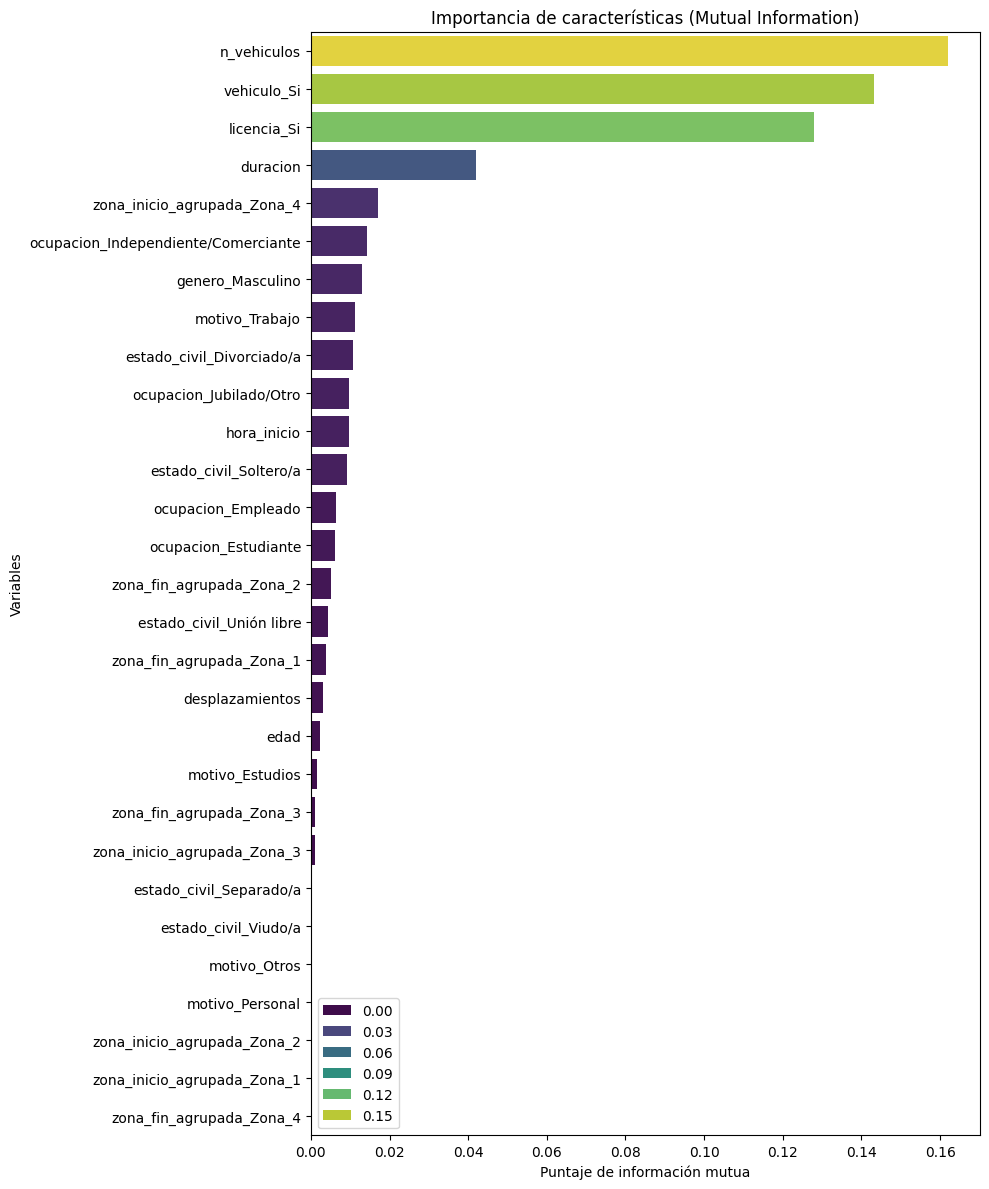

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Gráfico de barras
plt.figure(figsize=(10, 12))
sns.barplot(x=mi_scores.values, y=mi_scores.index,hue=mi_scores.values, palette="viridis")
plt.title("Importancia de características (Mutual Information)")
plt.xlabel("Puntaje de información mutua")
plt.ylabel("Variables")
plt.tight_layout()
plt.savefig('mi_scores.png')
plt.show()

In [ ]:
#Filtramos las que tenga una importancia mayor que 0.010
important_features = mi_scores[mi_scores > 0.010]

# Muestra los nombres de las variables
print(important_features.index.tolist())

['n_vehiculos', 'vehiculo_Si', 'licencia_Si', 'duracion', 'zona_inicio_agrupada_Zona_4', 'ocupacion_Independiente/Comerciante', 'genero_Masculino', 'motivo_Trabajo', 'estado_civil_Divorciado/a']


In [ ]:
X_encoded_important = X_encoded[important_features.index.tolist()]

In [ ]:
X_encoded_important

,n_vehiculos,vehiculo_Si,licencia_Si,duracion,zona_inicio_agrupada_Zona_4,ocupacion_Independiente/Comerciante,genero_Masculino,motivo_Trabajo,estado_civil_Divorciado/a
0,0,False,False,7,False,False,False,False,False
1,0,False,False,5,False,False,True,False,False
2,0,False,False,15,False,False,True,True,False
3,0,False,False,23,False,False,False,False,False
4,0,False,False,30,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
6106,0,False,False,40,False,True,True,False,False
6107,0,False,False,5,False,False,False,False,False
6108,0,False,False,35,False,False,False,False,False
6109,1,True,True,20,False,False,True,False,False


## Dividir datos

In [ ]:
#Dividir en Train y test
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X_encoded_important, y_resampled, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_resampled, test_size=0.2, random_state=42)

##Ramdon Forest

In [ ]:
times_excecution=[]

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import time
# Define los parámetros para la búsqueda en cuadrícula
param_grid_rf = {
    'n_estimators': [50,100, 200],  # Número de árboles
    'max_depth': [None,10, 20, 30],  # Profundidad máxima de los árboles
    'min_samples_split': [2,5, 10],  # Número mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1,2, 4],  # Número mínimo de muestras en una hoja
    'bootstrap': [True, False]  # Si usar bootstrap (muestreo con reemplazo)
}
# Crea el modelo RandomForest
rf_model = RandomForestClassifier(random_state=42)

# Crea el objeto GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf,
                              cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
# Ajusta el modelo con GridSearchCV
start_time = time.time()
grid_search_rf.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
times_excecution.append(execution_time)
# Obtén los mejores parámetros
best_params_rf = grid_search_rf.best_params_
print(f"Mejores parámetros Random Forest: {best_params_rf}")

# Realiza predicciones con los mejores parámetros
y_pred_rf = grid_search_rf.predict(X_test)

# Evalúa el rendimiento
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy con Random Forest: {accuracy_rf}')
#Metricas
print(classification_report(y_test, y_pred_rf, digits=4))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros Random Forest: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy con Random Forest: 0.7571545380212592
                          precision    recall  f1-score   support

Transporte no motorizado     0.8083    0.8046    0.8065       435
      Transporte público     0.7273    0.7037    0.7153       432
        Vehículo privado     0.7312    0.7640    0.7473       356

                accuracy                         0.7572      1223
               macro avg     0.7556    0.7574    0.7563      1223
            weighted avg     0.7572    0.7572    0.7570      1223



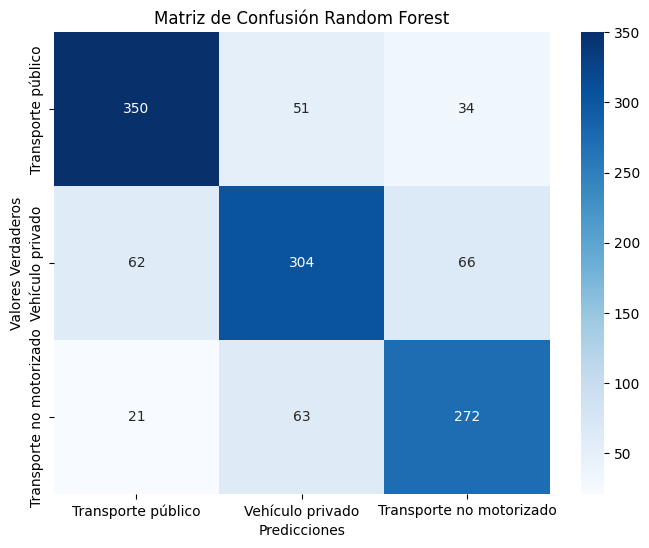

In [ ]:
#Matriz de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Calcula la matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

# Crea un mapa de calor de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
plt.title('Matriz de Confusión Random Forest')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.savefig('matriz_confusion_random_forest.png')
plt.show()

In [ ]:
#Guardar modelo
import joblib
joblib.dump(grid_search_rf, 'modelo_random_forest.pkl')

['modelo_random_forest.pkl']

## Decision Tree

In [ ]:
#Decion Tree
from sklearn.tree import DecisionTreeClassifier
# Define los parámetros para la búsqueda en cuadrícula
param_grid_dt = {
    'max_depth': [None,10, 20, 30],  # Profundidad máxima de los árboles
    'min_samples_split': [2,5, 10],  # Número mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1,2, 4],  # Número mínimo de muestras en una hoja
    'criterion': ['gini', 'entropy']  # Criterio de división
}
# Crea el modelo Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Crea el objeto GridSearchCV
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt,
                              cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
# Ajusta el modelo con GridSearchCV
start_time = time.time()
grid_search_dt.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
times_excecution.append(execution_time)
# Obtén los mejores parámetros
best_params_dt = grid_search_dt.best_params_
print(f"Mejores parámetros Decision Tree: {best_params_dt}")

# Realiza predicciones con los mejores parámetros
y_pred_dt = grid_search_dt.predict(X_test)

# Evalúa el rendimiento
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy con Decision Tree: {accuracy_dt}')
# Metricas
print(classification_report(y_test, y_pred_dt, digits=4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros Decision Tree: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy con Decision Tree: 0.6794766966475879
                          precision    recall  f1-score   support

Transporte no motorizado     0.6936    0.8276    0.7547       435
      Transporte público     0.6450    0.5509    0.5943       432
        Vehículo privado     0.6955    0.6545    0.6744       356

                accuracy                         0.6795      1223
               macro avg     0.6781    0.6777    0.6745      1223
            weighted avg     0.6770    0.6795    0.6747      1223



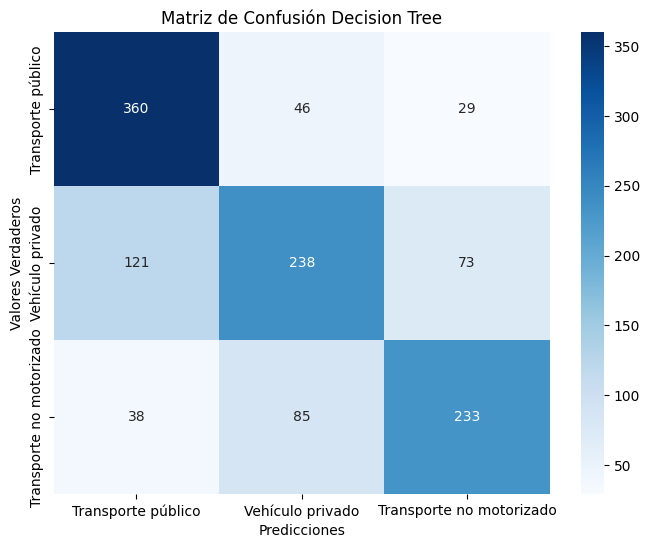

In [ ]:
#Matriz de confusion
from sklearn.metrics import confusion_matrix
# Calcula la matriz de confusión
cm = confusion_matrix(y_test, y_pred_dt)

# Crea un mapa de calor de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
plt.title('Matriz de Confusión Decision Tree')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.savefig('matriz_confusion_decision_tree.png')
plt.show()

In [ ]:
#Guardar modelo
import joblib
joblib.dump(grid_search_dt, 'modelo_decision_tree.pkl')

['modelo_decision_tree.pkl']

## XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
# Codificar las etiquetas de salida
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Definir la grilla de parámetros
param_grid_xgb = {
    'n_estimators': [100, 200],          # Número de árboles
    'max_depth': [3, 5, 7],              # Profundidad máxima de los árboles
    'learning_rate': [0.01, 0.1, 0.2],   # Tasa de aprendizaje
    'subsample': [0.8, 1.0],             # Fracción de datos a usar por árbol
    'colsample_bytree': [0.8, 1.0],      # Fracción de columnas a usar por árbol
    'gamma': [0, 1, 5]                   # Regularización para evitar overfitting
}

# Crear el modelo base
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Crear el GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Ajustar el modelo
start_time = time.time()
grid_search_xgb.fit(X_train, y_train_encoded)
end_time = time.time()

# Tiempo de ejecución
execution_time = end_time - start_time
times_excecution.append(execution_time)

# Mejores parámetros encontrados
best_params_xgb = grid_search_xgb.best_params_
print(f"Mejores parámetros XGBoost: {best_params_xgb}")

# Predicción en el conjunto de prueba
y_pred_xgb = grid_search_xgb.predict(X_test)

# Evaluación del modelo
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
print(f"Accuracy con XGBoost: {accuracy_xgb}")

# Reporte de clasificación con etiquetas originales
print(classification_report(y_test, le.inverse_transform(y_pred_xgb), digits=4))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:26:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mejores parámetros XGBoost: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy con XGBoost: 0.7301717089125103
                          precision    recall  f1-score   support

Transporte no motorizado     0.7574    0.7678    0.7626       435
      Transporte público     0.6976    0.6620    0.6793       432
        Vehículo privado     0.7339    0.7669    0.7500       356

                accuracy                         0.7302      1223
               macro avg     0.7296    0.7322    0.7306      1223
            weighted avg     0.7294    0.7302    0.7295      1223



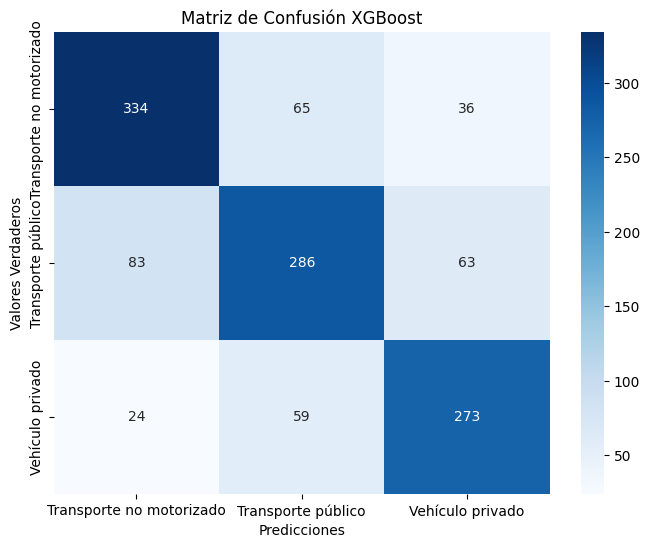

In [ ]:
# Decodificar predicciones y valores reales
y_test_labels = le.inverse_transform(y_test_encoded)
y_pred_labels = le.inverse_transform(y_pred_xgb)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)

# Graficar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión XGBoost')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.savefig('matriz_confusion_xgboost.png')
plt.show()

In [ ]:
#Guardar Modelo
import joblib
joblib.dump(grid_search_xgb, 'modelo_xgboost.pkl')

['modelo_xgboost.pkl']

In [ ]:
times_excecution

[570.2912323474884, 12.60930585861206, 366.657603263855]

## Support Vector Machine

In [ ]:
#SMV con Grid Search
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
import time
# Define los parámetros para la búsqueda en cuadrícula
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],  # Diferentes kernels
    'C': [0.1, 1, 10],  # Parámetro de penalización
    'gamma': ['scale', 'auto', 0.1, 1]  # Parámetro para el kernel rbf
}
# Crea el modelo SVM
svm_model = SVC(random_state=42)

# Crea el objeto GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           cv=5,  # Número de particiones para cross-validation
                           scoring='accuracy',  # Métrica a optimizar
                           n_jobs=-1,  # Usa todos los núcleos disponibles
                           verbose=1)  # Muestra el progreso
# Ajusta el modelo con GridSearchCV
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
times_excecution.append(execution_time)
# Obtén los mejores parámetros
best_params = grid_search.best_params_
print(f"Mejores parámetros: {best_params}")
# Realiza predicciones con los mejores parámetros
y_pred_svm = grid_search.predict(X_test)

# Evalúa el rendimiento
accuracy = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy con GridSearchCV: {accuracy}')
# metricas
print(classification_report(y_test, y_pred_svm))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:
#Matriz de confusion
from sklearn.metrics import confusion_matrix
# Calcula la matriz de confusión
cm = confusion_matrix(y_test, y_pred_svm)

# Crea un mapa de calor de la matriz de confusión
plt.figure  (figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
plt.title('Matriz de Confusión SVM')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.savefig('matriz_confusion_svm.png')
plt.show()


In [ ]:
#Guardar modelo
import joblib
joblib.dump(grid_search, 'modelo_svm.pkl')
